Aula 2 - Pré-processamento e Manipulação de Dados

- Pipeline de ML;
- Limpeza de dados: tratamento de valores nulos, outliers e categóricos;
- Normalização, padronização e codificação de variáveis;
- Divisão de treino/teste e validação cruzada.

## 🧩 Etapas do Pipeline de Machine Learning

O desenvolvimento de um modelo de Machine Learning não se resume apenas em "treinar e testar".  
Ele segue um **pipeline estruturado**, ou seja, uma sequência de etapas organizadas que garantem qualidade e confiabilidade nos resultados.  
As principais etapas são:

1️⃣ **Coleta de Dados**  
   - Reunir dados relevantes de diferentes fontes (bases públicas, bancos de dados, sensores, APIs, etc.).  
   - Importância: um modelo só pode ser tão bom quanto os dados que recebe. Dados ruins resultam em modelos ruins.

2️⃣ **Pré-processamento e Limpeza dos Dados**  
   - Tratamento de valores nulos, inconsistências, outliers e padronização de formatos.  
   - Importância: garante que o modelo trabalhe com informações corretas e comparáveis, reduzindo ruídos.

3️⃣ **Engenharia de Features**  
   - Criação, transformação e seleção de variáveis mais representativas para o problema.  
   - Importância: boas features podem aumentar significativamente o desempenho do modelo.

4️⃣ **Divisão dos Dados (Treino/Validação/Teste)**  
   - Separar o dataset em subconjuntos para treinar e avaliar o modelo de forma justa.  
   - Importância: evita overfitting e garante que o modelo generalize bem para novos dados.

5️⃣ **Treinamento do Modelo**  
   - Aplicar algoritmos de aprendizado supervisionado ou não supervisionado (ex.: Regressão, Árvores, Redes Neurais, K-Means).  
   - Importância: é onde o modelo "aprende" padrões a partir dos dados.

6️⃣ **Validação e Avaliação**  
   - Medir desempenho usando métricas adequadas (Accuracy, Precision, Recall, RMSE, R², etc.).  
   - Importância: garante que o modelo não apenas memorize, mas realmente capture os padrões relevantes.

7️⃣ **Ajuste de Hiperparâmetros (Tuning)**  
   - Testar diferentes configurações do algoritmo (ex.: profundidade da árvore, número de vizinhos no KNN).  
   - Importância: pode ser a diferença entre um modelo fraco e um modelo robusto.

8️⃣ **Implantação e Monitoramento**  
   - Disponibilizar o modelo em produção (API, dashboard, sistema interno) e acompanhar sua performance ao longo do tempo.  
   - Importância: modelos degradam com o tempo (conceito de *model drift*), por isso é essencial monitorar e re-treinar quando necessário.

---

✅ Em resumo: cada etapa do pipeline é fundamental para garantir que o modelo de Machine Learning seja **confiável, interpretável e útil para a tomada de decisão**.

📅 **Hoje:** Nós vamos estudar a etapa 2: **Pré-processamento dos dados**.



____

## 📅 Contexto

Imagine que você foi contratado como **cientista de dados júnior** em uma empresa que atua no setor de saúde.  
O time de BI disponibilizou um dataset do Kaggle: [Diabetes Dataset (Pima Indians Diabetes Database)](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database).  

Seu desafio é aplicar **técnicas de pré-processamento** para deixar os dados prontos para o treinamento de modelos de Machine Learning.

### 📥 **Etapa 1: Carregamento e Exploração inicial dos dados**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os 

In [3]:
current_path = os.getcwd()
current_path

'c:\\Users\\henrique.cordeiro\\OneDrive - Sociedade Campineira de Educação e Instrução\\A-POS\\LINGUAGEM DE PROGRAMAÇÃO PYTHON APLICADA A MACHINE LEARNING'

In [4]:
df = pd.read_csv(os.path.join(current_path,"diabetes.csv"))
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [5]:
#Vendo as primeiras linhas do dataframe
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
#Dimensão do dataframe
df.shape

(768, 9)

In [7]:
#Tipos de dados e valores nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [8]:
#Dados duplicados
df.loc[df.duplicated()]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome


In [9]:
#Análise estatística descritiva
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


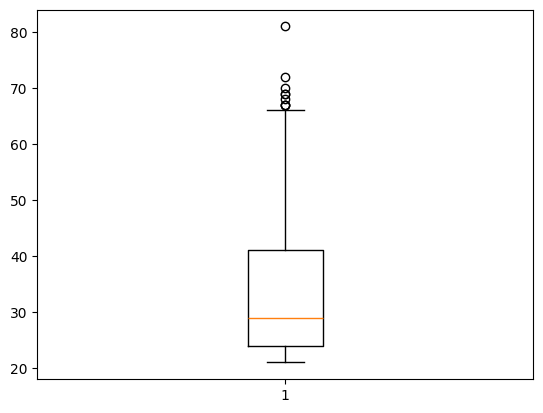

In [11]:
plt.boxplot(df['Age'])
plt.show()

In [15]:
Q_1 = df["Age"].quantile(.25)
Q_3 = df["Age"].quantile(.75)
IQR = Q_3 - Q_1

limite_inferior = Q_1 - 1.5 * IQR
limite_superior = Q_3 + 1.5 * IQR

In [17]:
limite_inferior

np.float64(-1.5)

In [18]:
limite_superior

np.float64(66.5)

In [24]:
df[(df["Age"] > limite_inferior ) | (df["Age"] < limite_superior)]


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


### 🧭 **Etapa 2: Valores Nulos e Constantes**

In [10]:
# Verificando valores nulos
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [11]:
# Verificando valores nulos
df.isna().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [13]:
# Colunas com valor constante
for coluna in df.columns:
  print(f'{coluna}: {df[coluna].nunique()}')

Pregnancies: 17
Glucose: 136
BloodPressure: 47
SkinThickness: 51
Insulin: 186
BMI: 248
DiabetesPedigreeFunction: 517
Age: 52
Outcome: 2


🔑 **Importância:**  
- Valores nulos podem distorcer o aprendizado do modelo.  
- Colunas constantes não carregam informação útil.  


### 📊 **Etapa 3 - Detecção de Outliers**

*Outlier* são dados diferentes dos outros pontos que podem causar problemas em procedimentos estatísticos (mudar uma média).

**Exemplo:** Mudar uma idade e ver a média.

* Solução 1: Ordenar os dados para encontrar outliers;
* Solução 2: Utilizar gráficos: dispersão, boxplot;
* Solução 3: Utilizar IQR para encontrar;
* Solução 4: Utilizar o Z-score.

In [14]:
array_1 = np.array([1,2,3,4,5])

In [15]:
array_1.mean()

np.float64(3.0)

In [16]:
array_2 = np.array([1,2,3,5, 40000000])

In [17]:
array_2.mean()

np.float64(8000002.2)

**Solução 1:**

In [18]:
df['Age'].describe()

,Age
count,768.000000
mean,33.240885
std,11.760232
min,21.000000
25%,24.000000
50%,29.000000
75%,41.000000
max,81.000000


**Solução 2:**

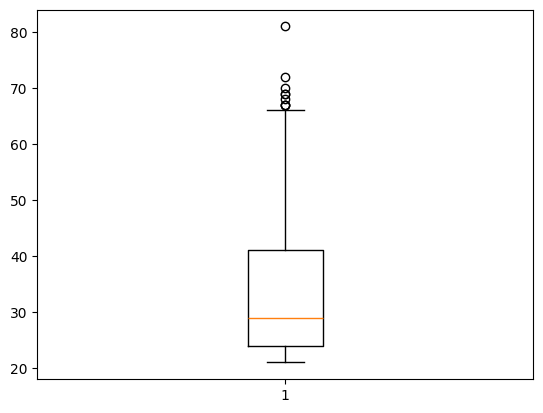

In [19]:
plt.boxplot(df['Age'])
plt.show()

**Solução 3:**

In [20]:
Q_1 = df['Age'].quantile(.25)
Q_3 = df['Age'].quantile(.75)
IQR = Q_3 - Q_1
lim_inf = Q_1 - 1.5 * IQR
lim_sup = Q_3 + 1.5 * IQR

In [21]:
lim_inf

np.float64(-1.5)

In [22]:
lim_sup

np.float64(66.5)

In [25]:
df[(df['Age'] > lim_sup) | (df['Age'] < lim_inf)].sort_values(by='Age')

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
363,4,146,78,0,0,38.5,0.520,67,1
489,8,194,80,0,0,26.1,0.551,67,0
537,0,57,60,0,0,21.7,0.735,67,0
674,8,91,82,0,0,35.6,0.587,68,0
123,5,132,80,0,0,26.8,0.186,69,0
684,5,136,82,0,0,0.0,0.640,69,0
666,4,145,82,18,0,32.5,0.235,70,1
453,2,119,0,0,0,19.6,0.832,72,0
459,9,134,74,33,60,25.9,0.460,81,0


**Solução 4:**

$$ Z = \frac{X-\mu}{σ} $$

In [26]:
z = (df['Age'] - df['Age'].mean()) / df['Age'].std()

In [27]:
z

,Age
0,1.425067
1,-0.190548
2,-0.105515
3,-1.040871
4,-0.020483
...,...
763,2.530487
764,-0.530677
765,-0.275580
766,1.169970


In [38]:
z[(z.values > 3) | (z.values < - 3)]

,Age
123,3.040681
453,3.295778
459,4.061069
666,3.125714
684,3.040681


### 🏷️ **Etapa 3: Tratamento de categóricas**

In [39]:
#Faixa etária: Jovem (≤ 30 anos), Adulto (31–50), Idoso (≥ 51).
df["Age_Group"] = pd.cut(df["Age"], bins=[20,30,50,100], labels=["Jovem","Adulto","Idoso"])
#IMC: Abaixo do peso, Normal, Sobrepeso, Obesidade.
df["BMI_Category"] = pd.cut(df["BMI"], bins=[0,18.5,24.9,29.9,100], labels=["Abaixo do peso","Normal","Sobrepeso","Obesidade"])
#Níveis de glicose: Normal (<100), Pré-diabetes (100–125), Diabetes (≥126)
df["Glucose_Category"] = pd.cut(df["Glucose"], bins=[0,100,125,300], labels=["Normal","Pré-diabetes","Diabetes"])
#Número de gestações (Pregnancies): Nenhuma, Poucas (1–3), Muitas (≥4)
df["Pregnancies_Category"] = pd.cut(df["Pregnancies"], bins=[-1,0,3,20], labels=["Nenhuma","Poucas","Muitas"])

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   Pregnancies               768 non-null    int64   
 1   Glucose                   768 non-null    int64   
 2   BloodPressure             768 non-null    int64   
 3   SkinThickness             768 non-null    int64   
 4   Insulin                   768 non-null    int64   
 5   BMI                       768 non-null    float64 
 6   DiabetesPedigreeFunction  768 non-null    float64 
 7   Age                       768 non-null    int64   
 8   Outcome                   768 non-null    int64   
 9   Age_Group                 768 non-null    category
 10  BMI_Category              757 non-null    category
 11  Glucose_Category          763 non-null    category
 12  Pregnancies_Category      768 non-null    category
dtypes: category(4), float64(2), int64(7)
memory usage:

In [41]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Age_Group,BMI_Category,Glucose_Category,Pregnancies_Category
0,6,148,72,35,0,33.6,0.627,50,1,Adulto,Obesidade,Diabetes,Muitas
1,1,85,66,29,0,26.6,0.351,31,0,Adulto,Sobrepeso,Normal,Poucas
2,8,183,64,0,0,23.3,0.672,32,1,Adulto,Normal,Diabetes,Muitas
3,1,89,66,23,94,28.1,0.167,21,0,Jovem,Sobrepeso,Normal,Poucas
4,0,137,40,35,168,43.1,2.288,33,1,Adulto,Obesidade,Diabetes,Nenhuma


**Ordinal encoder**

O ***Ordinal Encoding*** é uma técnica de codificação usada no pré-processamento de variáveis categóricas em aprendizado de máquina. Essa técnica é aplicada principalmente quando as categorias têm uma ordem intrínseca, ou seja, quando as categorias possuem uma relação ordinal ou hierárquica entre si.

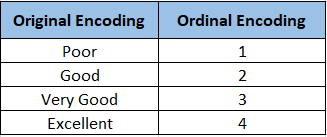

In [42]:
from sklearn.preprocessing import OrdinalEncoder

In [43]:
ordinal = OrdinalEncoder()

In [44]:
colunas_categoricas = df.select_dtypes('category').columns

In [45]:
colunas_categoricas

Index(['Age_Group', 'BMI_Category', 'Glucose_Category',
       'Pregnancies_Category'],
      dtype='object')

In [46]:
df_2 = df.copy()

In [48]:
#Usar o encoder
df_2[colunas_categoricas] = ordinal.fit_transform(df_2[colunas_categoricas])

In [49]:
df_2[colunas_categoricas]

,Age_Group,BMI_Category,Glucose_Category,Pregnancies_Category
0,0.0,2.0,0.0,0.0
1,0.0,3.0,1.0,2.0
2,0.0,1.0,0.0,0.0
3,2.0,3.0,1.0,2.0
4,0.0,2.0,0.0,1.0
...,...,...,...,...
763,1.0,2.0,2.0,0.0
764,2.0,2.0,2.0,2.0
765,2.0,3.0,2.0,0.0
766,0.0,2.0,0.0,2.0


**Onehot Encoder**

Aqui optarei pelo uso de outra biblioteca, a `category-encoders`. Para isso, é necessário fazer a sua instalação no ***Colab.***

O ***One-Hot Encoder*** é uma técnica de pré-processamento de dados usada para codificar variáveis categóricas em formato numérico, tornando-as adequadas para uso em algoritmos de aprendizado de máquina que requerem entradas numéricas. Esta técnica é especialmente útil quando se lida com variáveis categóricas que não possuem uma relação ordinal natural entre as categorias, ou seja, as categorias não têm uma ordem específica.

A saída desse ***encoder*** é uma matriz com uma coluna para cada classe da variável categórica em que 0 marca a ausência dessa classe na observação, e 1 marca a presença da classe na observação.

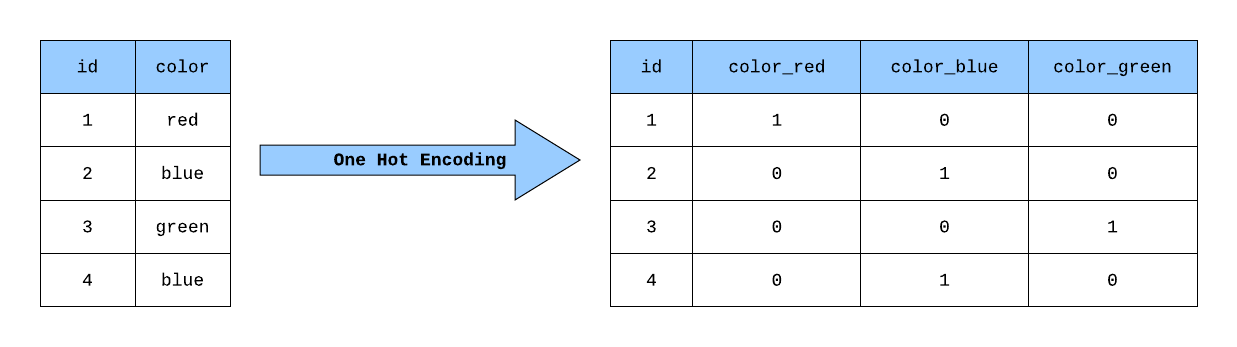

In [50]:
!pip install category-encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 4.1 MB/s eta 0:00:00


In [51]:
from category_encoders import OneHotEncoder

In [52]:
onehot = OneHotEncoder(cols= colunas_categoricas, use_cat_names=True)

In [53]:
df_3 = df.copy()

In [54]:
df_3 = onehot.fit_transform(df_3)

In [55]:
df_3

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Age_Group_Jovem,...,BMI_Category_Sobrepeso,BMI_Category_Obesidade,BMI_Category_nan,Glucose_Category_Normal,Glucose_Category_Pré-diabetes,Glucose_Category_Diabetes,Glucose_Category_nan,Pregnancies_Category_Nenhuma,Pregnancies_Category_Poucas,Pregnancies_Category_Muitas
0,6,148,72,35,0,33.6,0.627,50,1,0,...,0,1,0,0,0,1,0,0,0,1
1,1,85,66,29,0,26.6,0.351,31,0,0,...,1,0,0,1,0,0,0,0,1,0
2,8,183,64,0,0,23.3,0.672,32,1,0,...,0,0,0,0,0,1,0,0,0,1
3,1,89,66,23,94,28.1,0.167,21,0,1,...,1,0,0,1,0,0,0,0,1,0
4,0,137,40,35,168,43.1,2.288,33,1,0,...,0,1,0,0,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0,0,...,0,1,0,0,1,0,0,0,0,1
764,2,122,70,27,0,36.8,0.340,27,0,1,...,0,1,0,0,1,0,0,0,1,0
765,5,121,72,23,112,26.2,0.245,30,0,1,...,1,0,0,0,1,0,0,0,0,1
766,1,126,60,0,0,30.1,0.349,47,1,0,...,0,1,0,0,0,1,0,0,1,0


In [56]:
df_3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Pregnancies                    768 non-null    int64  
 1   Glucose                        768 non-null    int64  
 2   BloodPressure                  768 non-null    int64  
 3   SkinThickness                  768 non-null    int64  
 4   Insulin                        768 non-null    int64  
 5   BMI                            768 non-null    float64
 6   DiabetesPedigreeFunction       768 non-null    float64
 7   Age                            768 non-null    int64  
 8   Outcome                        768 non-null    int64  
 9   Age_Group_Jovem                768 non-null    int64  
 10  Age_Group_Adulto               768 non-null    int64  
 11  Age_Group_Idoso                768 non-null    int64  
 12  BMI_Category_Abaixo do peso    768 non-null    int

**Codificação**: transforma variáveis categóricas em números utilizáveis por modelos de ML.

### 📐 **Etapa 4 - Normalização e Padronização**

Quando trabalhamos com **pré-processamento de dados**, precisamos ajustar os formatos das variáveis para que possam ser utilizadas de forma eficiente pelos modelos de Machine Learning.  
Três técnicas fundamentais são: **Normalização, Padronização e Codificação de Variáveis**.  

---

#### 1️⃣ Normalização  
- **O que é?**  
  Escala os valores de uma variável para um intervalo fixo, geralmente entre **0 e 1**.  

- **Fórmula mais comum (Min-Max Scaling):**  
  $$
  x' = \frac{x - x_{min}}{x_{max} - x_{min}}
  $$

- **Quando usar?**  
  - Quando as variáveis possuem escalas muito diferentes.  
  - Essencial em modelos baseados em distância, como **KNN** e **Redes Neurais**.  

In [57]:
from sklearn.preprocessing import MinMaxScaler

In [60]:
colunas_numericas = df.select_dtypes('number').columns

In [61]:
colunas_numericas

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [62]:
scaler_MinMax = MinMaxScaler()

In [63]:
df_4 = df.copy()

In [64]:
df_4[colunas_numericas] = scaler_MinMax.fit_transform(df_4[colunas_numericas])

In [66]:
df_4[colunas_numericas].describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,0.226180,0.607510,0.566438,0.207439,0.094326,0.476790,0.168179,0.204015,0.348958
std,0.198210,0.160666,0.158654,0.161134,0.136222,0.117499,0.141473,0.196004,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.058824,0.497487,0.508197,0.000000,0.000000,0.406855,0.070773,0.050000,0.000000
50%,0.176471,0.587940,0.590164,0.232323,0.036052,0.476900,0.125747,0.133333,0.000000
75%,0.352941,0.704774,0.655738,0.323232,0.150414,0.545455,0.234095,0.333333,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


#### 2️⃣ Padronização  
- **O que é?**  
  Transforma os dados para que tenham **média 0** e **desvio padrão 1** (distribuição normalizada em torno da média).  

- **Fórmula (Z-score):**  
  $$
  z = \frac{x - \mu}{\sigma}
  $$

- **Quando usar?**  
  - Quando queremos comparar variáveis em diferentes escalas, mantendo a forma da distribuição.  
  - Muito usada em **Regressão Logística, SVM e PCA**.  

In [67]:
from sklearn.preprocessing import StandardScaler

In [68]:
scaler_std = StandardScaler()

In [69]:
df_5 = df.copy()

In [70]:
df_5[colunas_numericas] = scaler_std.fit_transform(df_5[colunas_numericas])

In [72]:
df_5[colunas_numericas].describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,7.680000e+02,7.680000e+02,7.680000e+02,7.680000e+02,7.680000e+02,7.680000e+02,7.680000e+02,7.680000e+02,7.680000e+02
mean,-6.476301e-17,-9.251859e-18,1.503427e-17,1.006140e-16,-3.006854e-17,2.590520e-16,2.451743e-16,1.931325e-16,7.401487e-17
std,1.000652e+00,1.000652e+00,1.000652e+00,1.000652e+00,1.000652e+00,1.000652e+00,1.000652e+00,1.000652e+00,1.000652e+00
min,-1.141852e+00,-3.783654e+00,-3.572597e+00,-1.288212e+00,-6.928906e-01,-4.060474e+00,-1.189553e+00,-1.041549e+00,-7.321202e-01
25%,-8.448851e-01,-6.852363e-01,-3.673367e-01,-1.288212e+00,-6.928906e-01,-5.955785e-01,-6.889685e-01,-7.862862e-01,-7.321202e-01
50%,-2.509521e-01,-1.218877e-01,1.496408e-01,1.545332e-01,-4.280622e-01,9.419788e-04,-3.001282e-01,-3.608474e-01,-7.321202e-01
75%,6.399473e-01,6.057709e-01,5.632228e-01,7.190857e-01,4.120079e-01,5.847705e-01,4.662269e-01,6.602056e-01,1.365896e+00
max,3.906578e+00,2.444478e+00,2.734528e+00,4.921866e+00,6.652839e+00,4.455807e+00,5.883565e+00,4.063716e+00,1.365896e+00


## Divisão treino/teste e validação cruzada

Normalmente, a nossa abordagem para separação dos dados tem sido o uso do ***train_test_split*** (separando em treino/teste), também conhecido como método ***Holdout***.

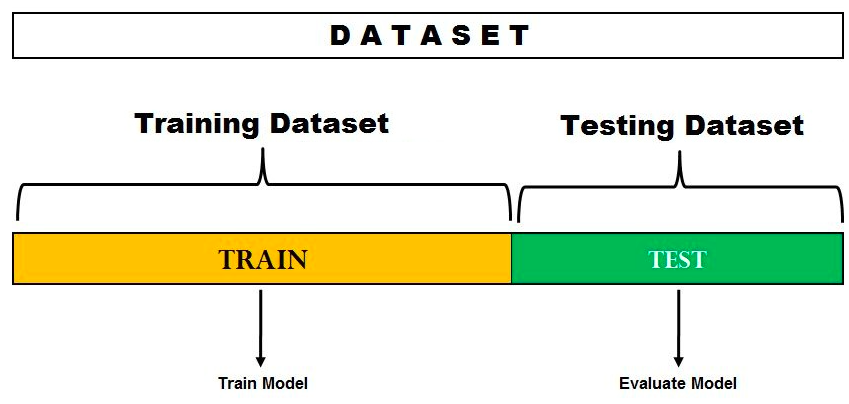

In [78]:
#Escolher as features e alvo
y = df['Outcome']
X = df.drop(columns=['Outcome','Age_Group','BMI_Category','Glucose_Category','Pregnancies_Category'])

In [79]:
y

,Outcome
0,1
1,0
2,1
3,0
4,1
...,...
763,0
764,0
765,0
766,1


In [80]:
X

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63
764,2,122,70,27,0,36.8,0.340,27
765,5,121,72,23,112,26.2,0.245,30
766,1,126,60,0,0,30.1,0.349,47


In [81]:
from sklearn.model_selection import train_test_split

In [82]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

In [83]:
X_train.shape

(514, 8)

In [84]:
X_test.shape

(254, 8)

Tal método **NÃO É ERRADO**, mas pode apresentar alguns problemas, e estes **tendem a ser mais perceptíveis dependendo do tamanho ou qualidade do conjunto de dados.**

Ou seja:

> Tamanho do *dataset* e/ou desequilíbrio das classes.

**Levante hipóteses do porquê o uso do *houldout* pode não ser o mais adequado nesses casos!**

In [ ]:
classe = [A, B, C] --> treino (k-folds), teste

### **Validação cruzada (*cross validation*)**

O cross validation (CV) é uma das técnicas mais importantes no ferramental de um cientista de dados.

Operacionalmente, o CV implementa diferentes conjuntos de treino e teste (aqui chamados de **validação**), criando efetivamente diferentes modelos treinados e avaliados em diferentes subconjuntos aleatórios (os chamados **folds**) da base de dados original.

No fim, é possível inspecionar as métricas de interesse em cada fold, bem como ter uma ideia da performance média do modelo, olhando para **a distribuição das métricas de avaliação**.

Note que este procedimento está intimamente relacionado com a avaliação da desejável habilidade de **generalização do modelo!**

A forma mais comum de fazermos CV é através da técnica **KFold**:

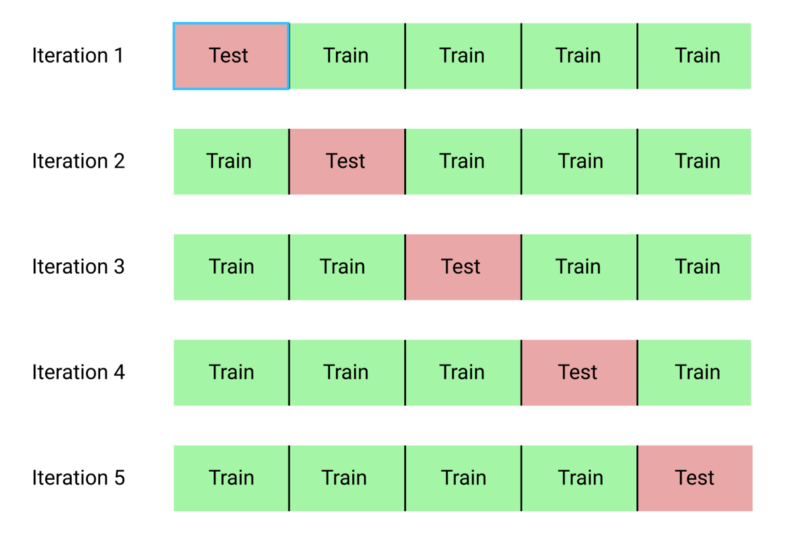

Vamos implementar o procedimento de CV utilizando o sklearn!

No [submódulo model_selection](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.model_selection), temos duas ferramentas muito importantes para o processo de CV:

- [KFold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html#sklearn.model_selection.KFold): classe que cria os *folds*.
- [cross_validate](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html#sklearn.model_selection.cross_validate): função que recebe os folds e os utiliza para o treinamento e avaliação cruzada de modelos, segundo a métrica definida.

Para ilustrar o CV,  amos utilizar os datasets artificiais que o sklearn proporciona:

### Modelagem usando *cross validation* com *KFold*

In [ ]:
from sklearn.model_selection import KFold, cross_validate